<a href="https://colab.research.google.com/github/NikolayIvTkachenko/Colab_Python_AI_NeuroNetwork/blob/main/Model_AI_cv_cnn_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import tensorflow as tf
import tensorflow_hub as hub

In [1]:
!wget -qq https://raw.githubusercontent.com/tensorflow/models/master/reasearch/object_detection/data/mscoco_complete_label_map.pbtxt

In [3]:
!wget -qq https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg

In [4]:
!wget -qq https://pjreddie.com/media/files/yolov3.weights

In [5]:
!wget -qq https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

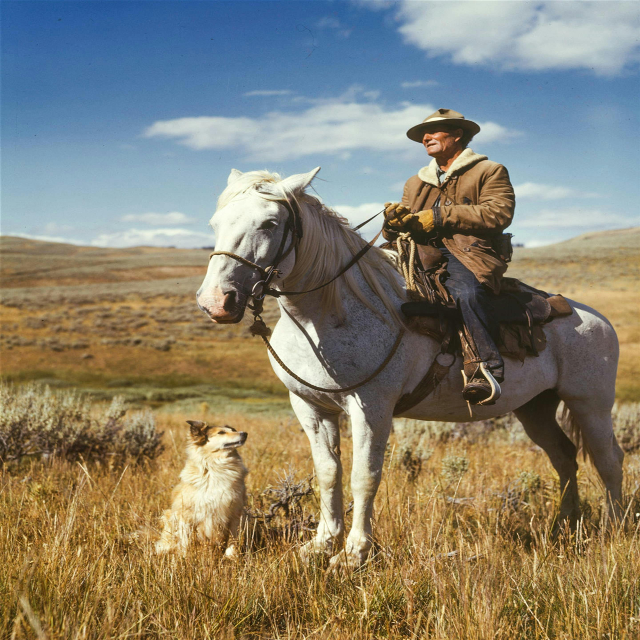

In [9]:
img = cv2.imread('horse.jpg')
img = cv2.resize(img, dsize=(640, 640))
cv2_imshow(img)

In [10]:
LABELS = list()
with open("/content/coco.names", "r") as file:
  for line in file:
    LABELS.append(line.strip())

In [11]:
BB_COLORS = np.random.randint(0, 255, size=(len(LABELS), 3))

In [12]:
model = cv2.dnn.readNetFromDarknet('yolov3.cfg', 'yolov3.weights')

In [13]:
prep_img = img / 255.0
prep_img = prep_img.transpose(2, 0, 1)
prep_img = np.expand_dims(prep_img, 0)

In [14]:
print(img.shape)
print(prep_img.shape)

(640, 640, 3)
(1, 3, 640, 640)


In [37]:
output_layers = model.getUnconnectedOutLayersNames()
model.setInput(prep_img)
detector_output = model.forward(output_layers)

In [38]:
output_layers

('yolo_82', 'yolo_94', 'yolo_106')

In [39]:
print(len(detector_output))
for output in detector_output:
  print(output.shape)

3
(1200, 85)
(4800, 85)
(19200, 85)


In [41]:
def get_bounding_boxes(detector_outputs):
  bounding_boxes = []
  confidences = []
  class_ids = []
  (H, W) = img.shape[:2]

  for output in detector_outputs:
    for detection in output:
      detection_scores = detection[5:]
      class_id = np.argmax(detection_scores)
      confidence = detection_scores[class_id]
      if confidence > 0.5:
        centerX, centerY, width, height = np.array([detection[0] * W, detection[1] * H, detection[2] * W, detection[3] * H])
        x = round(centerX - (width / 2))
        y = round(centerY - (height / 2))

        bounding_boxes.append([x, y, round(width), round(height)])
        confidences.append(confidence)
        class_ids.append(class_id)
  return bounding_boxes, confidences, class_ids

In [42]:
bounding_boxes, confidences, class_ids = get_bounding_boxes(detector_output)

In [43]:
indices = cv2.dnn.NMSBoxes(bounding_boxes, confidences, 0.5, 0.3)

In [44]:
def draw_bounding_boxes_yolo(img, indices, bounding_boxes, confidences, class_ids, colors, labels):
  if len(indices) > 0:
    for i in indices.flatten():
      (x, y) = (bounding_boxes[i][0], bounding_boxes[i][1])
      (w, h) = (bounding_boxes[i][2], bounding_boxes[i][3])

      color = [int(c) for c in colors[class_ids[i]]]
      cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)

      text = "{0}: {1:.4f}".format(labels[class_ids[i]], confidences[i])
      cv2.putText(img, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
  return img

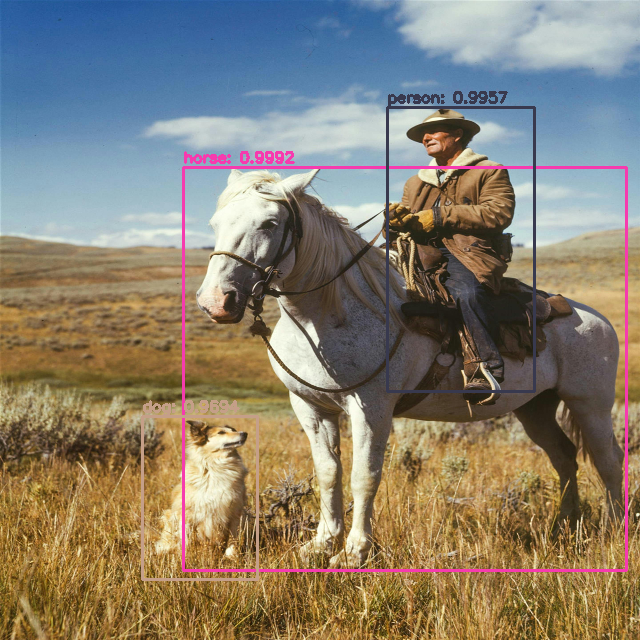

In [45]:
output_img = draw_bounding_boxes_yolo(img, indices, bounding_boxes, confidences, class_ids, BB_COLORS, LABELS)
cv2_imshow(output_img)

In [ ]:
#https://github.com/pjreddie/darknet
#